In [1]:
import numpy as np
import pandas as pd
from astropy.table import Table

import minimint
import imf

import matplotlib.pyplot as plt

#minimint.download_and_prepare()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import datetime

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
hplanck = 6.62607015e-27   # erg*s
clight = 2.99792458e10     # cm/s
pi = np.pi


def compute_snr(m, nexp, texp, fiber_diameter=107):
    """
    Compute photon counts and SNR for DESI and Spec-S5 instruments
    given an input AB magnitude, number of exposures, and total exposure time.
    
    Parameters
    ----------
    m : float
        Source AB magnitude
    nexp : int
        Number of exposures
    texp : float
        Effective exposure time per exposure (seconds)
    fiber_diameter : needs to be either 107 or 120 (in microns)
    
    Returns
    -------
    dict
        Dictionary containing wavelength array, photon counts, SNR arrays and VRAD_ERR for both systems .
    """
    
    # --- Physical constants ---
    hplanck = 6.62607015e-27   # erg*s
    clight = 2.99792458e10     # cm/s

    # --- Throughput data ---
    lam_t = np.array([360.,375,400.,450.,500.,550.,600.,650.,700.,750.,800.,850.,900.,980.]) * 10.0  # Å

    if fiber_diameter == 107: # ... for Spec-S5 (107 micron fiber and 0.96 arcsec seeing)
        thru_s5 = np.array([0.0373, 0.0526, 0.0740, 0.1122, 0.1089, 0.1015, 0.1169, 
                            0.125, 0.1237, 0.1138, 0.1368, 0.1378, 0.1387, 0.0895])
        thru_s5_sky = np.array([0.0959, 0.1343, 0.1871, 0.2813, 0.2716, 0.2529, 0.2920, 
                                0.3133, 0.3109, 0.2865, 0.3444, 0.3471, 0.3497, 0.2261])
        df_s5 = 1.02  # arcsec fiber diameter (approximate)
    elif fiber_diameter == 120:
        thru_s5 = np.array([0.0422,0.0596, 0.0837,  0.1269, 0.1231, 0.1147, 0.1322, 
                            0.1414, 0.14,   0.1288, 0.1548, 0.156,  0.1569, 0.1012])
        thru_s5_sky = np.array([0.0959, 0.1343, 0.1871, 0.2813, 0.2716, 0.2529, 0.2920, 
                                0.3133, 0.3109, 0.2865, 0.3444, 0.3471, 0.3497, 0.2261])
        df_s5 = 1.144  # arcsec fiber diameter
    else:
        raise ValueError("fiber_diameter must be either the baseline of 107 microns or the larger dia of 120 microns.")


    # ... for DESI (107 micron fiber and 0.96 arcsec seeing) - baseline design
    thru_d = np.array([0.0253,0.0409,0.0623,0.0863,0.0940,0.0933,0.1117,0.1216,0.1231,0.1155,0.1433,0.1456,0.1440,0.0845])
    thru_d_sky = np.array([0.0631,0.1017,0.1537,0.2113,0.2284,0.2262,0.2716,0.2976,0.3033,0.2859,0.3558,0.3619,0.3586,0.2107])
    df_d = 1.51  # arcsec fiber diameter for 107 micron diameter fibers

    # --- Telescope diameters (cm) ---
    d_d = 3.797e2
    d_s5 = 6.0e2

    # --- Sky spectrum (erg/s/cm^2/Å/arcsec^2) ---
    flamsky = np.array([1.69E-17,1.50E-17,1.22E-17,1.59E-17,1.03E-17,1.02E-17,
                        9.59E-18,7.89E-18,8.02E-18,7.73E-18,7.76E-18,7.73E-18,5.86E-18,8.00E-18])
    phsky = flamsky / (hplanck * clight * 1e8 / lam_t)   # photons/s/cm^2/Å/arcsec^2

    # --- Convert AB magnitude to photon flux ---
    fnu = 10**(-0.4*(m + 48.6)) * np.ones_like(lam_t)
    flam = fnu * (clight * 1e8) / (lam_t**2)
    phot = flam / (hplanck * clight * 1e8 / lam_t)

    # --- Noise terms ---
    noise_ccd_d = np.array([3.35]*6 + [2.72]*8)
    noise_ccd_s5 = np.array([1.18]*6 + [2.72]*8)

    # --- DESI ---
    ph_d = phot * pi * (d_d/2)**2 * texp * thru_d
    phsky_d = phsky * pi * (d_d/2)**2 * texp * pi * (df_d/2)**2 * thru_d_sky
    noise_d = np.sqrt(phsky_d + nexp * noise_ccd_d**2)
    snr_d = ph_d / noise_d

    # --- Spec-S5 ---
    ph_s5 = phot * pi * (d_s5/2)**2 * texp * thru_s5
    phsky_s5 = phsky * pi * (d_s5/2)**2 * texp * pi * (df_s5/2)**2 * thru_s5_sky
    noise_s5 = np.sqrt(phsky_s5 + nexp * noise_ccd_s5**2)
    snr_s5 = ph_s5 / noise_s5

    # --- Interpolate to fine wavelength grid ---
    lam = np.linspace(lam_t.min(), lam_t.max(), 1001)
    interp_snr_d = interp1d(lam_t, snr_d, kind='cubic')
    interp_snr_s5 = interp1d(lam_t, snr_s5, kind='cubic')
    interp_ph_d = interp1d(lam_t, ph_d, kind='cubic')
    interp_ph_s5 = interp1d(lam_t, ph_s5, kind='cubic')

    snr_d_lam = interp_snr_d(lam)
    snr_s5_lam = interp_snr_s5(lam)
    ph_d_lam = interp_ph_d(lam)
    ph_s5_lam = interp_ph_s5(lam)

    # --- Velocity error example (S5 red arm) ---
    i = (lam_t > 7470.) & (lam_t < 9800.)
    VRAD_ERR = 10.0**(1.389 - 0.975*np.log10(np.median(snr_s5[i])) - 0.975*np.log10(0.8)) 
        # last term to convert from per DESI pixel to per Angstrom

    return {
        "lam": lam,
        "snr_d_lam": snr_d_lam,
        "snr_s5_lam": snr_s5_lam,
        "ph_d_lam": ph_d_lam,
        "ph_s5_lam": ph_s5_lam,
        "lam_t": lam_t,
        "snr_d_t": snr_d,
        "snr_s5_t": snr_s5,
        "ph_d_t": ph_d,
        "ph_s5_t": ph_s5,
        "VRAD_ERR": VRAD_ERR,
        "fiber_diameter": fiber_diameter,
        "abmag":m,
        "exptime":texp,
        "nexp":nexp
    }

In [3]:
def luminosity_from_Mv(Mv, Mv_sun=4.83):
    """
    Convert absolute V magnitude to luminosity in solar units.

    Parameters
    ----------
    Mv : float or array-like
        Absolute V magnitude(s) of the object(s).
    Mv_sun : float, optional
        Solar absolute V magnitude (default 4.83).

    Returns
    -------
    L_over_Lsun : float or ndarray
        Luminosity in units of the Sun's luminosity.
    """
    Mv = np.asarray(Mv, dtype=float)
    return 10.0 ** (0.4 * (Mv_sun - Mv))


def Mv_from_luminosity(L_over_Lsun, Mv_sun=4.83):
    """
    Convert luminosity (in solar units) to absolute V magnitude.

    Parameters
    ----------
    L_over_Lsun : float or array-like
        Luminosity in units of the Sun's luminosity (dimensionless).
    Mv_sun : float, optional
        Solar absolute V magnitude (default 4.83).

    Returns
    -------
    Mv : float or ndarray
        Absolute V magnitude(s) corresponding to the input luminosity.
    """
    L_over_Lsun = np.asarray(L_over_Lsun, dtype=float)
    return Mv_sun - 2.5 * np.log10(L_over_Lsun)

In [4]:
def compute_sigma_vrad_err(vrad_err, sigma_vrad):
    """
    Compute the velocity dispersion error from the individual radial velocity errors.

    Parameters
    ----------
    vrad_err : array-like
        Array of individual radial velocity errors (km/s).
    sigma_vrad : float
        Error on the individual radial velocities (km/s).

    Returns
    -------
    sigma_vrad_err : float
        Estimated error on the velocity dispersion (km/s).
    """
    ivar_sigma_vrad = 2 * sigma_vrad**2 * np.sum(1 / (vrad_err**2 + sigma_vrad**2)**2)
    return ivar_sigma_vrad**(-0.5)



In [5]:
def wolf_mass(sigma_vrad, rhalf):
    """
    Compute the mass within the half-light radius using the Wolf et al. (2010) formula (Eq. 2).

    Parameters
    ----------
    sigma_vrad : float
        Velocity dispersion in km/s.
    rhalf : float
        Half-light radius in parsecs.

    Returns
    -------
    M_half : float
        Mass within the half-light radius in solar masses.
    """
    return 930  * sigma_vrad**2 * 3/4 * rhalf


def frac_wolf_mass_err(sigma_vrad, sigma_vrad_err, rhalf, rhalf_err):
    """
    Compute the fractional uncertainty on the Wolf mass estimate.
    
    For M = 697.5 * sigma^2 * rhalf, using standard error propagation:
    (dM/M)^2 = 4*(dsigma/sigma)^2 + (drhalf/rhalf)^2
    
    Parameters
    ----------
    sigma_vrad : float
        Velocity dispersion in km/s.
    sigma_vrad_err : float
        Uncertainty on velocity dispersion in km/s.
    rhalf : float
        Half-light radius in parsecs.
    rhalf_err : float
        Uncertainty on half-light radius in parsecs.
    
    Returns
    -------
    M_err : float
        Fractional uncertainty on the Wolf mass.
    """
    # Compute the mass
    M = wolf_mass(sigma_vrad, rhalf)
    
    # Fractional uncertainties
    frac_sigma = sigma_vrad_err / sigma_vrad
    frac_rhalf = rhalf_err / rhalf
    
    # Total fractional uncertainty on mass
    frac_M_err = np.sqrt(4 * frac_sigma**2 + frac_rhalf**2)
    
    return frac_M_err


def wolf_mass_error(sigma_vrad, sigma_vrad_err, rhalf, rhalf_err):
    """
    Compute the absolute uncertainty on the Wolf mass estimate.
    
    Parameters
    ----------
    sigma_vrad : float
        Velocity dispersion in km/s.
    sigma_vrad_err : float
        Uncertainty on velocity dispersion in km/s.
    rhalf : float
        Half-light radius in parsecs.
    rhalf_err : float
        Uncertainty on half-light radius in parsecs.
    
    Returns
    -------
    M_err : float
        Absolute uncertainty on the Wolf mass in solar masses.
    """
    M = wolf_mass(sigma_vrad, rhalf)
    frac_M_err = frac_wolf_mass_err(sigma_vrad, sigma_vrad_err, rhalf, rhalf_err)
    
    return M * frac_M_err


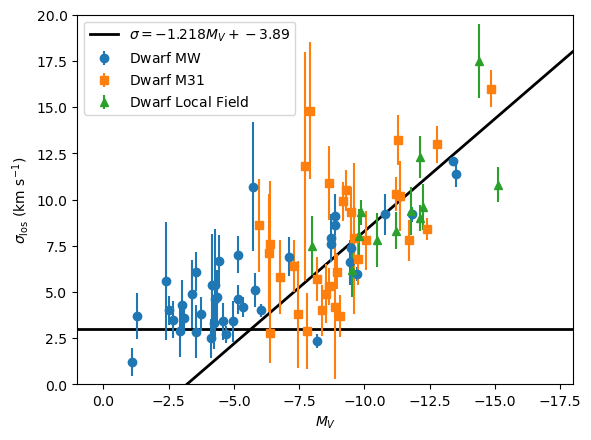

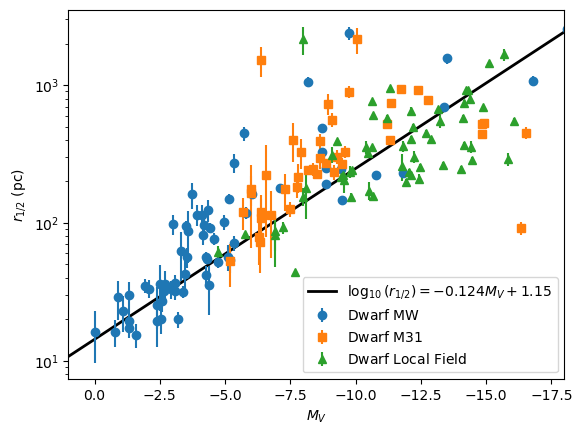

In [ ]:
dsph_mw = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_mw.csv'
).to_pandas()
dsph_m31 = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_m31.csv'
).to_pandas()
dsph_lf = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_local_field.csv'
).to_pandas()

# Combine all three datasets
M_V_combined = np.concatenate([dsph_mw['M_V'], dsph_m31['M_V'], dsph_lf['M_V']])
vlos_sigma_combined = np.concatenate([dsph_mw['vlos_sigma'], dsph_m31['vlos_sigma'], dsph_lf['vlos_sigma']])
# Calculate uncertainties as mean of upper and lower errors
vlos_sigma_err_mw = 0.5 * (dsph_mw['vlos_sigma_em'] + dsph_mw['vlos_sigma_ep'])
vlos_sigma_err_m31 = 0.5 * (dsph_m31['vlos_sigma_em'] + dsph_m31['vlos_sigma_ep'])
vlos_sigma_err_lf = 0.5 * (dsph_lf['vlos_sigma_em'] + dsph_lf['vlos_sigma_ep'])
vlos_sigma_err_combined = np.concatenate([vlos_sigma_err_mw, vlos_sigma_err_m31, vlos_sigma_err_lf])
# Remove NaN values
mask = np.isfinite(M_V_combined) & np.isfinite(vlos_sigma_combined) & np.isfinite(vlos_sigma_err_combined)
M_V_fit = M_V_combined[mask]
vlos_sigma_fit = vlos_sigma_combined[mask]
vlos_sigma_err_fit = vlos_sigma_err_combined[mask]
# Fit linear relation: sigma = a * M_V + b (weighted by uncertainties)
weights = 1.0 / vlos_sigma_err_fit**2
coeffs = np.polyfit(M_V_fit, vlos_sigma_fit, 1, w=weights)
a, b = coeffs
# Generate model for plotting
M_V_model = np.linspace(-18, 1, 100)
vlos_sigma_model = a * M_V_model + b
# Generate model for plotting
M_V_model = np.linspace(-18, 1, 100)
vlos_sigma_model = a * M_V_model + b
plt.plot(M_V_model, vlos_sigma_model, 'k-', linewidth=2, 
         label=f'$\\sigma = {a:.3f} M_V + {b:.2f}$')
plt.axhline(3, c='k', lw=2)
plt.errorbar(dsph_mw['M_V'], dsph_mw['vlos_sigma'], yerr=np.mean([dsph_mw['vlos_sigma_em'], dsph_mw['vlos_sigma_ep']], axis=0), fmt='o', label=r'${\rm Dwarf~MW}$')
plt.errorbar(dsph_m31['M_V'], dsph_m31['vlos_sigma'], yerr=np.mean([dsph_m31['vlos_sigma_em'], dsph_m31['vlos_sigma_ep']], axis=0), fmt='s', label=r'${\rm Dwarf~M31}$')
plt.errorbar(dsph_lf['M_V'], dsph_lf['vlos_sigma'], yerr=np.mean([dsph_lf['vlos_sigma_em'], dsph_lf['vlos_sigma_ep']], axis=0), fmt='^', label=r'${\rm Dwarf~Local~Field}$')
plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'$\sigma_{\rm los}~({\rm km~s^{-1}})$')
plt.gca().set_xlabel(r'$M_V$')
plt.legend()
plt.xlim(1, -18)
plt.ylim(0, 20)
plt.show()


# Combine all three datasets for half-light radius
M_V_combined_r = np.concatenate([dsph_mw['M_V'], dsph_m31['M_V'], dsph_lf['M_V']])
rhalf_combined = np.concatenate([dsph_mw['rhalf_sph_physical'], 
                                  dsph_m31['rhalf_sph_physical'], 
                                  dsph_lf['rhalf_sph_physical']])
# Calculate uncertainties as mean of upper and lower errors
rhalf_err_mw = 0.5 * (dsph_mw['rhalf_sph_physical_em'] + dsph_mw['rhalf_sph_physical_ep'])
rhalf_err_m31 = 0.5 * (dsph_m31['rhalf_sph_physical_em'] + dsph_m31['rhalf_sph_physical_ep'])
rhalf_err_lf = 0.5 * (dsph_lf['rhalf_sph_physical_em'] + dsph_lf['rhalf_sph_physical_ep'])
rhalf_err_combined = np.concatenate([rhalf_err_mw, rhalf_err_m31, rhalf_err_lf])
# Remove NaN values and non-positive values (can't take log)
mask_r = (np.isfinite(M_V_combined_r) & np.isfinite(rhalf_combined) & 
          np.isfinite(rhalf_err_combined) & (rhalf_combined > 0))
M_V_fit_r = M_V_combined_r[mask_r]
rhalf_fit = rhalf_combined[mask_r]
rhalf_err_fit = rhalf_err_combined[mask_r]
# Fit in log space: log10(rhalf) = a * M_V + b
# Propagate errors: d(log10(x)) = dx / (x * ln(10))
log_rhalf_fit = np.log10(rhalf_fit)
log_rhalf_err_fit = rhalf_err_fit / (rhalf_fit * np.log(10))
# Weighted fit
weights_r = 1.0 / log_rhalf_err_fit**2
coeffs_r = np.polyfit(M_V_fit_r, log_rhalf_fit, 1, w=weights_r)
a_r, b_r = coeffs_r
# Generate model for plotting
M_V_model_r = np.linspace(-18, 1, 100)
log_rhalf_model = a_r * M_V_model_r + b_r
rhalf_model = 10**log_rhalf_model
plt.plot(M_V_model_r, rhalf_model, 'k-', linewidth=2, 
         label=f'$\\log_{{10}}(r_{{1/2}}) = {a_r:.3f} M_V + {b_r:.2f}$')
plt.errorbar(dsph_mw['M_V'], dsph_mw['rhalf_sph_physical'], yerr=np.mean([dsph_mw['rhalf_sph_physical_em'], dsph_mw['rhalf_sph_physical_ep']], axis=0), fmt='o', label=r'${\rm Dwarf~MW}$')
plt.errorbar(dsph_m31['M_V'], dsph_m31['rhalf_sph_physical'], yerr=np.mean([dsph_m31['rhalf_sph_physical_em'], dsph_m31['rhalf_sph_physical_ep']], axis=0), fmt='s', label=r'${\rm Dwarf~M31}$')
plt.errorbar(dsph_lf['M_V'], dsph_lf['rhalf_sph_physical'], yerr=np.mean([dsph_lf['rhalf_sph_physical_em'], dsph_lf['rhalf_sph_physical_ep']], axis=0), fmt='^', label=r'${\rm Dwarf~Local~Field}$')
plt.gca().invert_xaxis()
plt.gca().set_yscale('log')
plt.gca().set_ylabel(r'$r_{1/2}~({\rm pc})$')
plt.gca().set_xlabel(r'$M_V$')
plt.legend()
plt.xlim(1, -18)
# plt.ylim(0, 20)
plt.show()

In [7]:
def compute_sigma_from_Mv(Mv):
    """
    Compute the velocity dispersion (sigma) from the absolute V magnitude (Mv)
    using the fitted relation from the combined dataset of dwarf galaxies.

    Parameters
    ----------
    mv : float or array-like
        Absolute V magnitude(s) of the object(s).

    Returns
    -------
    sigma : float or ndarray
        Estimated velocity dispersion in km/s corresponding to the input Mv.
    """
    return np.max([-1.218 * Mv -3.89, 3])

def compute_rhalf_from_mv(mv):
    """
    Compute the half-light radius (rhalf) from the absolute V magnitude (Mv)
    using the fitted relation from the combined dataset of dwarf galaxies.

    Parameters
    ----------
    mv : float or array-like
        Absolute V magnitude(s) of the object(s).

    Returns
    -------
    rhalf : float or ndarray
        Estimated half-light radius in parsecs corresponding to the input Mv.
    """
    log_rhalf = -0.124 * mv + 1.15
    return 10**log_rhalf

In [8]:
texp = 1800
nexp = 3
vrad_err_cutoff = 10.0  # km/s

z_list = np.linspace(15, 25, 101)
vrad_err = np.zeros_like(z_list)
for i, zmag in enumerate(z_list):
    result = compute_snr(m=zmag, nexp=nexp, texp=texp, fiber_diameter=107)
    vrad_err[i] = result['VRAD_ERR']
z_cutoff = np.max(z_list[vrad_err < vrad_err_cutoff])
print(f"Maximum z magnitude for VRAD_ERR < {vrad_err_cutoff} km/s: {z_cutoff:.2f}")

vrad_err_interp = interp1d(z_list, vrad_err, kind='cubic', bounds_error=False, fill_value='extrapolate')

Maximum z magnitude for VRAD_ERR < 10.0 km/s: 22.00


Distance = 10.0 kpc, n_star = 1.0e+04
L_z = 1.67e+03 L_sun, M_v = -3.22, n_obs = 493
Estimated sigma_vrad = 3.00 km/s with error = 0.16 km/s
Estimated Wolf mass = 2.23e+05 Msun with error = 2.42e+04 Msun
Estimated fractional error on Wolf mass = 0.11
Distance = 10.0 kpc, n_star = 1.0e+05
L_z = 1.64e+04 L_sun, M_v = -5.71, n_obs = 4923
Estimated sigma_vrad = 3.06 km/s with error = 0.05 km/s
Estimated Wolf mass = 4.72e+05 Msun with error = 1.61e+04 Msun
Estimated fractional error on Wolf mass = 0.03
Distance = 10.0 kpc, n_star = 1.0e+06
L_z = 1.58e+05 L_sun, M_v = -8.17, n_obs = 50365
Estimated sigma_vrad = 6.06 km/s with error = 0.03 km/s
Estimated Wolf mass = 3.73e+06 Msun with error = 3.10e+04 Msun
Estimated fractional error on Wolf mass = 0.01
Distance = 10.0 kpc, n_star = 1.0e+07
L_z = 1.60e+06 L_sun, M_v = -10.68, n_obs = 498868
Estimated sigma_vrad = 9.12 km/s with error = 0.01 km/s
Estimated Wolf mass = 1.73e+07 Msun with error = 4.08e+04 Msun
Estimated fractional error on Wolf m

/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_94756/3155144841.py:18: RuntimeWarning: divide by zero encountered in scalar power
  return ivar_sigma_vrad**(-0.5)


L_z = 1.58e+04 L_sun, M_v = -5.67, n_obs = 0
Estimated sigma_vrad = 3.02 km/s with error = inf km/s
Estimated Wolf mass = 4.52e+05 Msun with error = inf Msun
Estimated fractional error on Wolf mass = inf
Distance = 1000.0 kpc, n_star = 1.0e+06
L_z = 1.56e+05 L_sun, M_v = -8.15, n_obs = 3
Estimated sigma_vrad = 6.04 km/s with error = 5.26 km/s
Estimated Wolf mass = 3.68e+06 Msun with error = 6.42e+06 Msun
Estimated fractional error on Wolf mass = 1.74
Distance = 1000.0 kpc, n_star = 1.0e+07
L_z = 1.60e+06 L_sun, M_v = -10.68, n_obs = 66
Estimated sigma_vrad = 9.12 km/s with error = 1.26 km/s
Estimated Wolf mass = 1.73e+07 Msun with error = 4.76e+06 Msun
Estimated fractional error on Wolf mass = 0.28
Distance = 1000.0 kpc, n_star = 1.0e+08
L_z = 1.59e+07 L_sun, M_v = -13.17, n_obs = 663
Estimated sigma_vrad = 12.16 km/s with error = 0.44 km/s
Estimated Wolf mass = 6.26e+07 Msun with error = 4.55e+06 Msun
Estimated fractional error on Wolf mass = 0.07


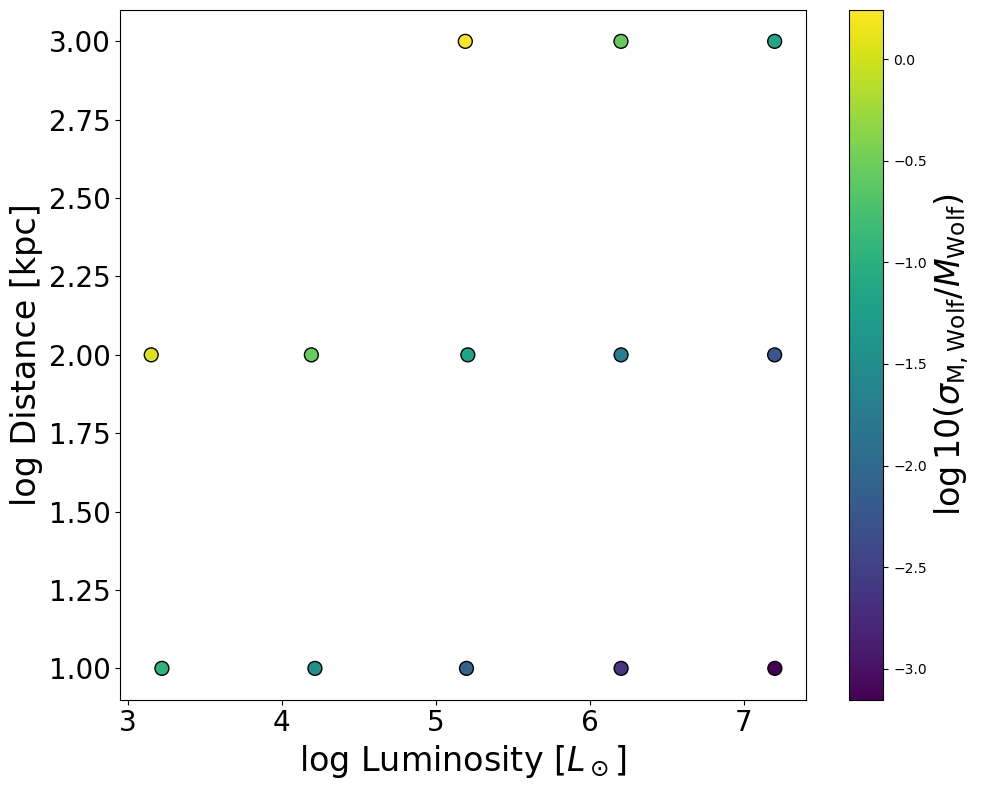

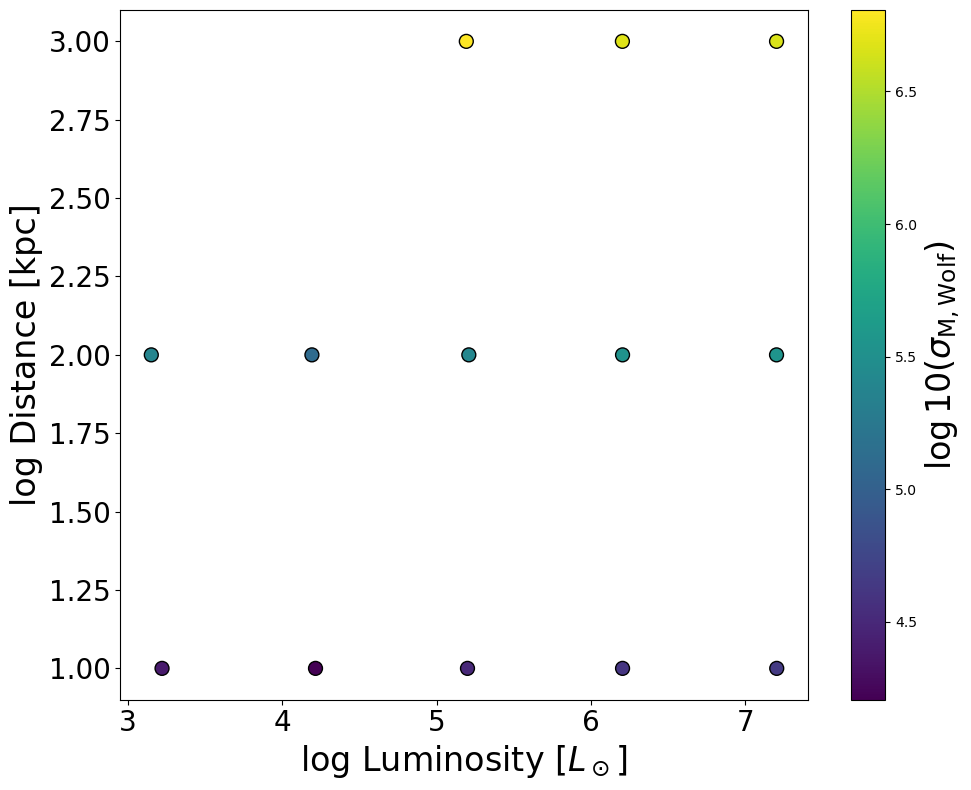

In [23]:
def compute_enclosed_mass_error(n_star, distance, vrad_err_interp, age=12e9, feh=-2, f_obs=0.5, plot=True):
    # Interpolator for isochrones
    mi_iso = minimint.Interpolator(['DECam_g', 'DECam_r', 'DECam_z', 'Bessell_V'])
    
    # Sample mass n_star from Chabrier IMF
    mass = imf.chabrier2005.distr.rvs(int(n_star))

    # Remove stars with mass > 1 Msun (gone by t ~ 12 Gyr)
    mass = mass[mass < 1]

    # Sample mass, log(age), metallicity
    qq = mi_iso(mass, np.log10(age), -2)

    # Remove WDs
    xind = np.isfinite(qq['Bessell_V']) & np.isfinite(qq['DECam_z'])

    # Convert from mag to flux/luminosity
    starflux = luminosity_from_Mv(qq['Bessell_V'][xind])

    # Compute the total luminosity (in L_sun) and M_v of the system
    M_v = Mv_from_luminosity(np.sum(starflux))
    L_v = np.sum(starflux)
    # Distance Modulus
    dm = 5.0 * np.log10(distance) + 10.0

    # Apparent Magnitudes
    g = qq['DECam_g'][xind] + dm
    r = qq['DECam_r'][xind] + dm
    z = qq['DECam_z'][xind] + dm

    # Apply zmag cutoff
    xind2 = z < z_cutoff
    g = g[xind2]
    r = r[xind2]
    z = z[xind2]

    # Subset of stars that would be observed (within rhalf)
    xind3 = np.random.rand(len(z)) < f_obs
    g = g[xind3]
    r = r[xind3]
    z = z[xind3]
    print(f"L_z = {L_v:.2e} L_sun, M_v = {M_v:.2f}, n_obs = {len(z)}")
    
    if plot:
        plt.hist(qq['DECam_z'][xind] + dm, bins=np.linspace(12, 28, 17), alpha=0.5, label='All Stars')
        plt.hist(z, bins=np.linspace(12, 28, 17), alpha=0.5, label='Observed')
        plt.axvline(z_cutoff, c='k', linestyle='--', label=f'z cutoff = {z_cutoff:.2f}')
        plt.xlabel('z')
        plt.legend()
        plt.show()

        plt.scatter(
            qq['DECam_g'][xind] - qq['DECam_r'][xind],
            qq['DECam_z'][xind] + dm
        )
        plt.axhline(z_cutoff, c='k', linestyle='--', label=f'z cutoff = {z_cutoff:.2f}')
        plt.xlabel('g - r')
        plt.ylabel('z')
        plt.gca().invert_yaxis()
        plt.show()
        
    # Calculate VRAD_ERR for each observed star
    # vrad_err = np.zeros_like(z)
    # for i, zmag in enumerate(z):
    #     result = compute_snr(m=zmag, nexp=nexp, texp=texp, fiber_diameter=107)
    #     vrad_err[i] = result['VRAD_ERR']
    vrad_err = vrad_err_interp(z)

    if plot:
        plt.hist(vrad_err, bins=20)
        plt.xlabel('VRAD_ERR (km/s)')
        plt.show()
        
    # Compute velocity dispersion and its error
    sigma_vrad = compute_sigma_from_Mv(M_v)
    sigma_vrad_err = compute_sigma_vrad_err(vrad_err, sigma_vrad)
    print(f"Estimated sigma_vrad = {sigma_vrad:.2f} km/s with error = {sigma_vrad_err:.2f} km/s")
    
    # Compute Fractional error on Wolf mass
    rhalf = compute_rhalf_from_mv(M_v)
    frac_M_err = frac_wolf_mass_err(sigma_vrad, sigma_vrad_err, rhalf, 0)
    M_err = wolf_mass_error(sigma_vrad, sigma_vrad_err, rhalf, 0)
    print(f"Estimated Wolf mass = {wolf_mass(sigma_vrad, rhalf):.2e} Msun with error = {M_err:.2e} Msun")
    print(f"Estimated fractional error on Wolf mass = {frac_M_err:.2f}")

    return {
        "M_v": M_v,
        "L_v": L_v,
        "n_obs": len(z),
        "sigma_vrad": sigma_vrad,
        "sigma_vrad_err": sigma_vrad_err,
        "rhalf": rhalf,
        "frac_M_err": frac_M_err,
        "M_err": M_err,
    }

log_D = np.linspace(1, 3, 3)
log_n_star = np.linspace(4, 8, 5)
D = []
M_v = []
L_v = []
n_obs = []
sigma_vrad = []
sigma_vrad_err = []
rhalf = []
frac_M_err = []
M_err = []
for log_d in log_D:
    for log_n in log_n_star:
        print(f"Distance = {10**log_d:.1f} kpc, n_star = {10**log_n:.1e}")
        result = compute_enclosed_mass_error(n_star=10**log_n, distance=10**log_d, vrad_err_interp=vrad_err_interp, age=12e9, feh=-2, f_obs=0.5, plot=False)
        D.append(10**log_d)
        M_v.append(result['M_v'])
        L_v.append(result['L_v'])
        n_obs.append(result['n_obs'])
        sigma_vrad.append(result['sigma_vrad'])
        sigma_vrad_err.append(result['sigma_vrad_err'])
        rhalf.append(result['rhalf'])
        frac_M_err.append(result['frac_M_err'])
        M_err.append(result['M_err'])
        
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(np.log10(L_v), np.log10(D), c=np.log10(frac_M_err), cmap='viridis', s=100, ec='k')
# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log10(\sigma_\mathrm{M,Wolf}/M_\mathrm{Wolf})$', fontsize=24)
# Labels and title
ax.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=24)
ax.set_ylabel('log Distance [kpc]', fontsize=24)
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(np.log10(L_v), np.log10(D), c=np.log10(M_err), cmap='viridis', s=100, ec='k')
# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log10(\sigma_\mathrm{M,Wolf})$', fontsize=24)
# Labels and title
ax.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=24)
ax.set_ylabel('log Distance [kpc]', fontsize=24)
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

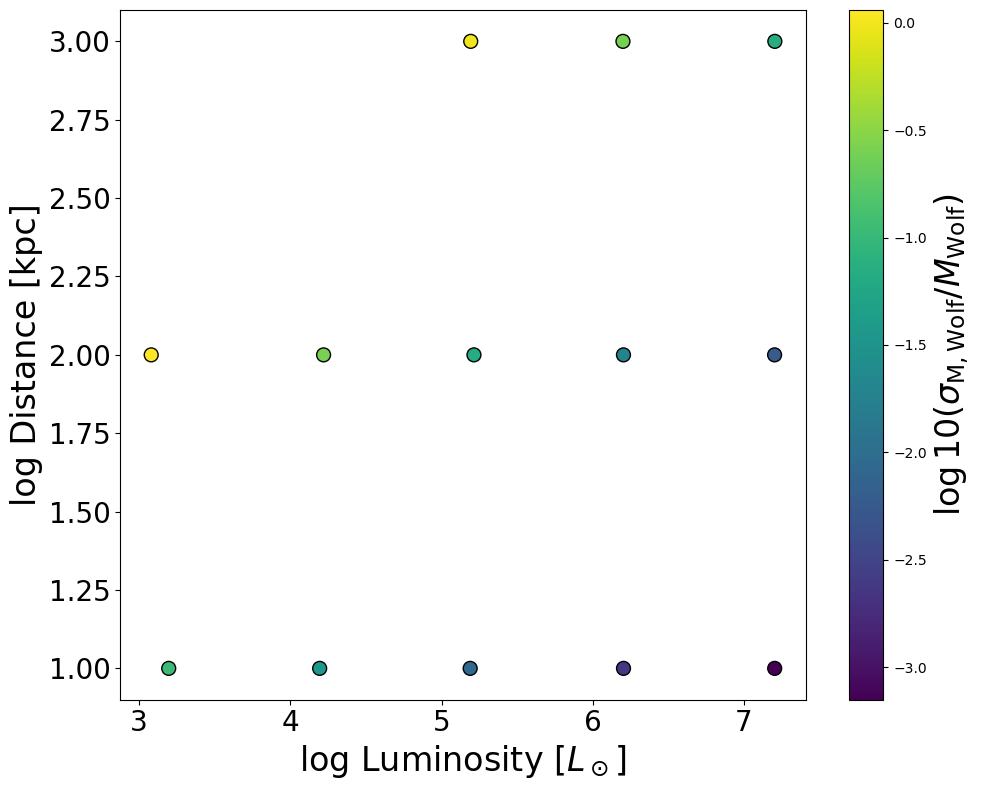

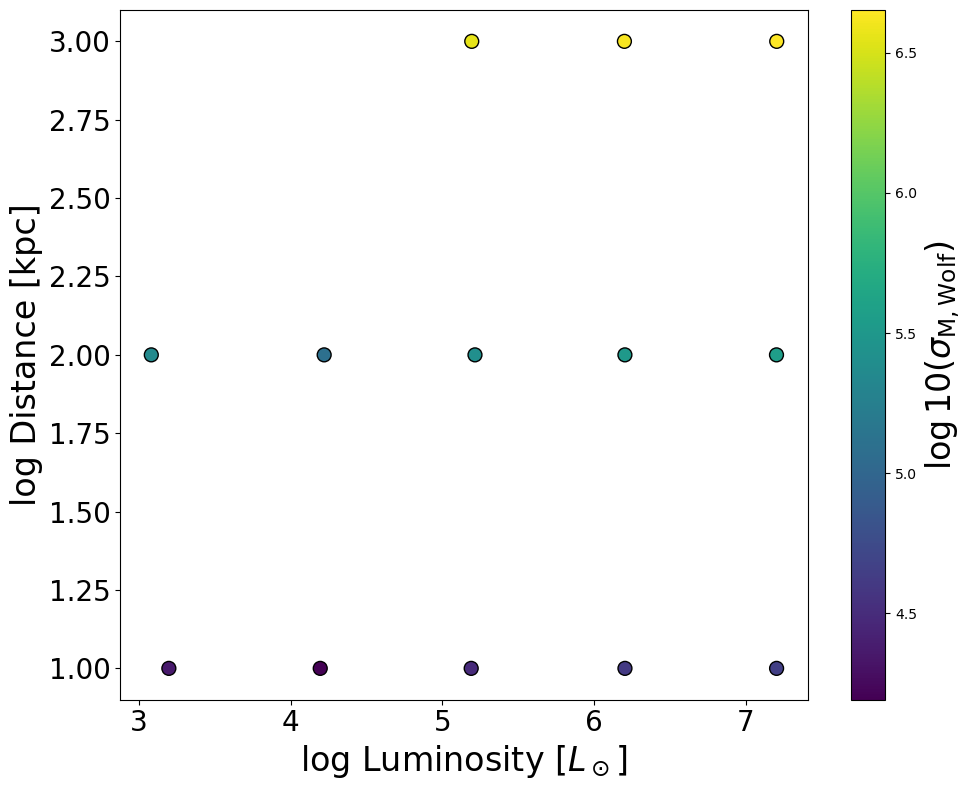

In [19]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(np.log10(L_v), np.log10(D), c=np.log10(frac_M_err), cmap='viridis', s=100, ec='k')
# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log10(\sigma_\mathrm{M,Wolf}/M_\mathrm{Wolf})$', fontsize=24)
# Labels and title
ax.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=24)
ax.set_ylabel('log Distance [kpc]', fontsize=24)
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(np.log10(L_v), np.log10(D), c=np.log10(M_err), cmap='viridis', s=100, ec='k')
# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log10(\sigma_\mathrm{M,Wolf})$', fontsize=24)
# Labels and title
ax.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=24)
ax.set_ylabel('log Distance [kpc]', fontsize=24)
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

L_z = 3.20e+05 L_sun, M_v = -8.93, n_obs = 1857


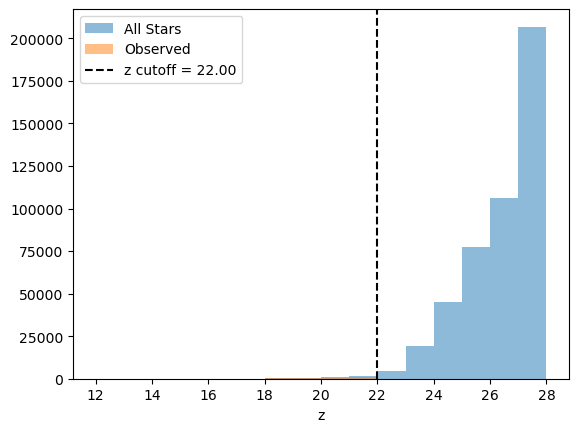

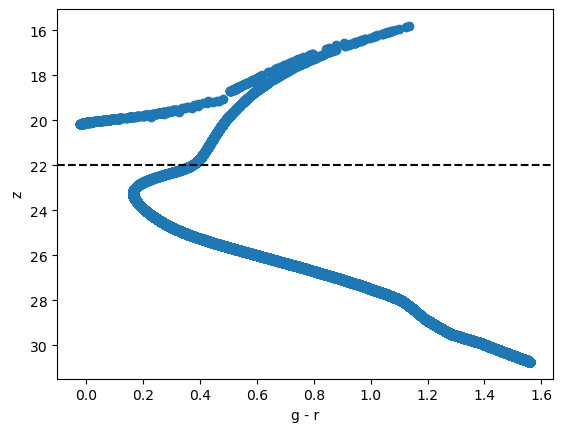

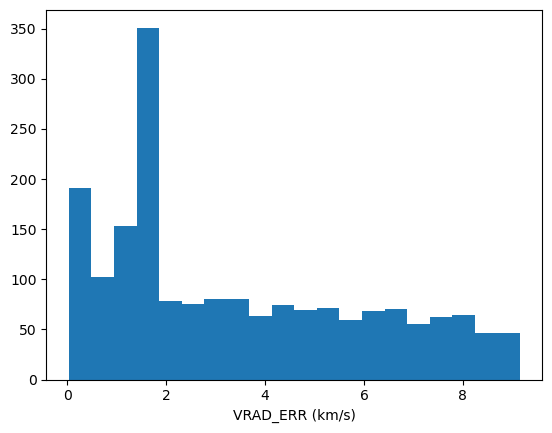

Estimated sigma_vrad = 6.99 km/s with error = 0.14 km/s
Estimated Wolf mass = 6.17e+06 Msun with error = 2.48e+05 Msun
Estimated fractional error on Wolf mass = 0.04


{'M_v': np.float64(-8.93295695419762),
 'L_v': np.float64(320024.1713210925),
 'n_obs': 1857,
 'sigma_vrad': np.float64(6.990341570212699),
 'sigma_vrad_err': np.float64(0.14078249971126078),
 'rhalf': np.float64(181.00337062150174),
 'frac_M_err': np.float64(0.04027914753441071),
 'M_err': np.float64(248489.44117237863)}

In [22]:
compute_enclosed_mass_error(
    n_star=2e6, 
    distance=80, 
    vrad_err_interp=vrad_err_interp, 
    age=12e9, 
    feh=-2, 
    f_obs=0.5, 
    plot=True
)

In [18]:
dsph_mw[dsph_mw["key"] == "draco_1"]["M_V"]

19   -8.87
Name: M_V, dtype: float64